<a href="https://colab.research.google.com/github/Jake0925/DeepLearning/blob/master/%EC%95%A4%EB%93%9C%EB%A5%98_2%EC%A3%BC%EC%B0%A8_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C1_%EA%B8%B0%EB%B3%B8_numpy%EB%A5%BC%ED%86%B5%ED%95%9C%ED%95%A8%EC%88%98%EA%B5%AC%ED%98%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/fakhre-alam/Deep-Learning/blob/master/Python%2BBasics%2BWith%2BNumpy%2Bv3.ipynb
https://github.com/robd2/coursera/blob/master/Python+Basics+With+Numpy+v3.md

# 시그모이드

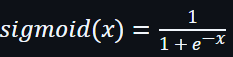


1) math를 사용한 경우
- 매트릭스나 벡터(배열)값을 한번에 처리할수 없다

In [1]:
import math

def sigmoid(x):
  y = 1 / (1 + math.exp(-x))
  return y

y_hat = sigmoid(3)
y_hat

0.9525741268224334

2) numpy사용한경우
- 매트릭스나 벡터(배열)값을 한번에 처리할수 있다

In [3]:
import numpy as np

def sigmoid_np(arr):
  #방법1
  # y = 1 / (1 + np.exp(np.dot(arr, (-1))))

  #방법2
  nparr = np.array(arr)
  y = 1 / (1 + np.exp(-nparr))
  return y

x = [1,2,3]
y_hat = sigmoid_np(x)
y_hat

array([0.73105858, 0.88079708, 0.95257413])

# 시그모이드 미분 (gradient)

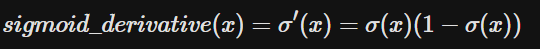

In [13]:
def derivative (x):
  X_np = np.array(x)
  s = 1 / (1 + np.exp(-X_np))
  dev = s * (1- s)
  return dev

In [14]:
x = [1,2,3]
dev = derivative(x)
dev

array([0.19661193, 0.10499359, 0.04517666])

# 배열 재구성

In [40]:
def image2vector(image):
    """
    Argument:
    image -- a numpy array of shape (length, height, depth)

    Returns:
    v -- a vector of shape (length*height*depth, 1)
    """
    print('image shape: ', image.shape)
    v= image.reshape(image.shape[0]*image.shape[1]*image.shape[2], 1)
    print('v shape: ', v.shape)
    return v

In [41]:
# This is a 3 by 3 by 2 array, typically images will be (num_px_x, num_px_y,3) where 3 represents the RGB values
image = np.array([[[ 0.67826139,  0.29380381],
        [ 0.90714982,  0.52835647],
        [ 0.4215251 ,  0.45017551]],

       [[ 0.92814219,  0.96677647],
        [ 0.85304703,  0.52351845],
        [ 0.19981397,  0.27417313]],

       [[ 0.60659855,  0.00533165],
        [ 0.10820313,  0.49978937],
        [ 0.34144279,  0.94630077]]])
image2vector(image)

# print ("image2vector(image) = " + str(image2vector(image)))

image shape:  (3, 3, 2)
v shape:  (18, 1)


array([[0.67826139],
       [0.29380381],
       [0.90714982],
       [0.52835647],
       [0.4215251 ],
       [0.45017551],
       [0.92814219],
       [0.96677647],
       [0.85304703],
       [0.52351845],
       [0.19981397],
       [0.27417313],
       [0.60659855],
       [0.00533165],
       [0.10820313],
       [0.49978937],
       [0.34144279],
       [0.94630077]])

# 데이터 정규화

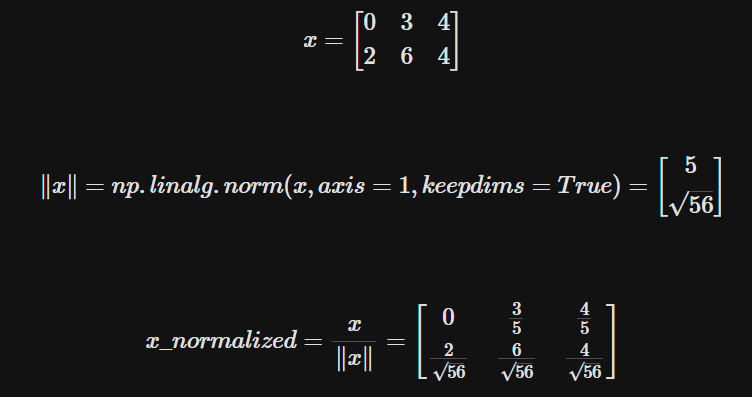

In [44]:
# 행에 대한 정규화
def normalizeRows(x):
  norm_col = np.linalg.norm(x, axis=1, keepdims=True)
  norm_x = x / norm_col # 요소간 나눗셈
  return norm_x



In [45]:
x = np.array([
    [0, 3, 4],
    [1, 6, 4]])
print("normalizeRows(x) = " + str(normalizeRows(x)))

normalizeRows(x) = [[0.         0.6        0.8       ]
 [0.13736056 0.82416338 0.54944226]]


# 브로드캐스팅과 소프트맥스 함수

**Instructions**:
- $ \text{for } x \in \mathbb{R}^{1\times n} \text{,     } softmax(x) = softmax(\begin{bmatrix}
    x_1  &&
    x_2 &&
    ...  &&
    x_n  
\end{bmatrix}) = \begin{bmatrix}
     \frac{e^{x_1}}{\sum_{j}e^{x_j}}  &&
    \frac{e^{x_2}}{\sum_{j}e^{x_j}}  &&
    ...  &&
    \frac{e^{x_n}}{\sum_{j}e^{x_j}}
\end{bmatrix} $

- $\text{for a matrix } x \in \mathbb{R}^{m \times n} \text{,  $x_{ij}$ maps to the element in the $i^{th}$ row and $j^{th}$ column of $x$, thus we have: }$  $$softmax(x) = softmax\begin{bmatrix}
    x_{11} & x_{12} & x_{13} & \dots  & x_{1n} \\
    x_{21} & x_{22} & x_{23} & \dots  & x_{2n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    x_{m1} & x_{m2} & x_{m3} & \dots  & x_{mn}
\end{bmatrix} = \begin{bmatrix}
    \frac{e^{x_{11}}}{\sum_{j}e^{x_{1j}}} & \frac{e^{x_{12}}}{\sum_{j}e^{x_{1j}}} & \frac{e^{x_{13}}}{\sum_{j}e^{x_{1j}}} & \dots  & \frac{e^{x_{1n}}}{\sum_{j}e^{x_{1j}}} \\
    \frac{e^{x_{21}}}{\sum_{j}e^{x_{2j}}} & \frac{e^{x_{22}}}{\sum_{j}e^{x_{2j}}} & \frac{e^{x_{23}}}{\sum_{j}e^{x_{2j}}} & \dots  & \frac{e^{x_{2n}}}{\sum_{j}e^{x_{2j}}} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    \frac{e^{x_{m1}}}{\sum_{j}e^{x_{mj}}} & \frac{e^{x_{m2}}}{\sum_{j}e^{x_{mj}}} & \frac{e^{x_{m3}}}{\sum_{j}e^{x_{mj}}} & \dots  & \frac{e^{x_{mn}}}{\sum_{j}e^{x_{mj}}}
\end{bmatrix} = \begin{pmatrix}
    softmax\text{(first row of x)}  \\
    softmax\text{(second row of x)} \\
    ...  \\
    softmax\text{(last row of x)} \\
\end{pmatrix} $$

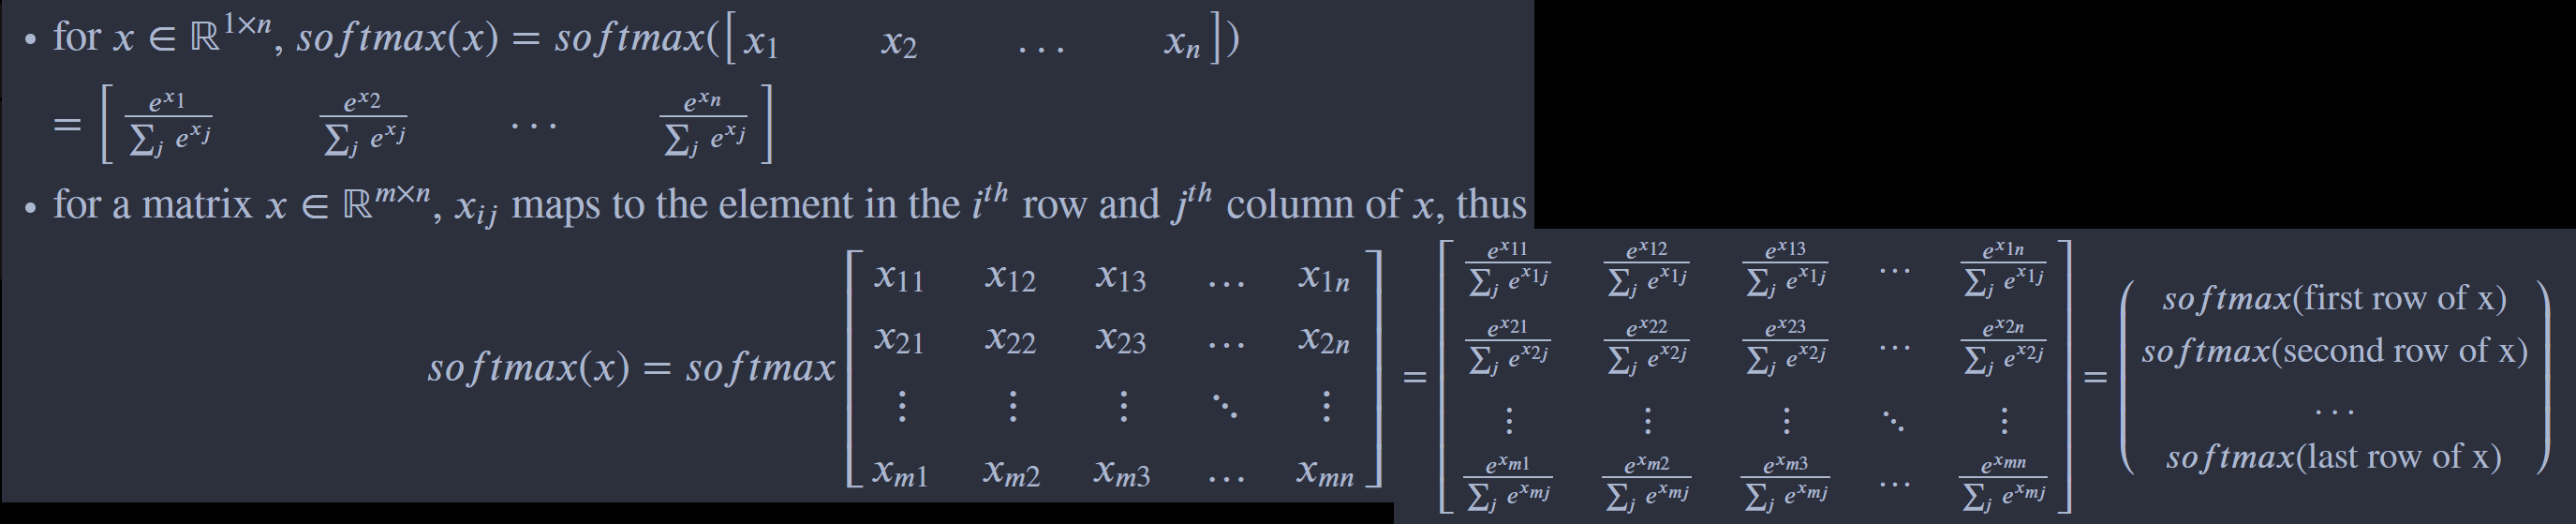

In [48]:
def softmax(x):
    x_exp = np.exp(x)
    x_exp_sum_col = np.sum(x_exp, axis=1, keepdims=True) # 각 행의 합
    sm = x_exp / x_exp_sum_col # 각 요소의 나누셈

    return sm

In [49]:
x = np.array([
    [9, 2, 5, 0, 0],
    [7, 5, 0, 0 ,0]])
print("softmax(x) = " + str(softmax(x)))

softmax(x) = [[9.80897665e-01 8.94462891e-04 1.79657674e-02 1.21052389e-04
  1.21052389e-04]
 [8.78679856e-01 1.18916387e-01 8.01252314e-04 8.01252314e-04
  8.01252314e-04]]


# 벡터화

딥러닝에서는 매우 큰 데이터 세트를 다룹니다. 따라서 계산적으로 최적화되지 않은 함수는 알고리즘에서 큰 병목 현상이 될 수 있으며 실행하는 데 오랜 시간이 걸리는 모델이 될 수 있습니다. 코드가 계산적으로 효율적인지 확인하려면 벡터화를 사용합니다

In [10]:
import time
from time import time, sleep

1) 직접구현한 경우

In [8]:
x1 = [9, 2, 5, 0, 0, 7, 5, 0, 0, 0, 9, 2, 5, 0, 0]
x2 = [9, 2, 2, 9, 0, 9, 2, 5, 0, 0, 9, 2, 5, 0, 0]

### DOT ###
tic = time()
dot = 0
for i in range(len(x1)):
    dot+= x1[i]*x2[i]
toc = time()
print (" dot = " + str(dot) + "\n dot 연산시간 = " + str(1000*(toc - tic)) + "ms")


### OUTER ###
tic = time()
outer = np.zeros((len(x1),len(x2)))
for i in range(len(x1)):
    for j in range(len(x2)):
        outer[i,j] = x1[i]*x2[j]
toc = time()
print (" outer = " + str(outer) + "\n outer 연산시간 = " + str(1000*(toc - tic)) + "ms")


### ELEMENTWISE ###
tic = time()
mul = np.zeros(len(x1))
for i in range(len(x1)):
    mul[i] = x1[i]*x2[i]
toc = time()
print (" elementwise multiplication = " + str(mul) + "\n elementwise multiplication 연산시간 = " + str(1000*(toc - tic)) + "ms")


###  GENERAL DOT ###
W = np.random.rand(3,len(x1)) # Random 3*len(x1) numpy array
tic = time()
gdot = np.zeros(W.shape[0])
for i in range(W.shape[0]):
    for j in range(len(x1)):
        gdot[i] += W[i,j]*x1[j]
toc = time()
print (" gdot = " + str(gdot) + "\n gdot 연산시간 = " + str(1000*(toc - tic)) + "ms")

 dot = 278
 dot 연산시간 = 0.11563301086425781ms
 outer = [[81. 18. 18. 81.  0. 81. 18. 45.  0.  0. 81. 18. 45.  0.  0.]
 [18.  4.  4. 18.  0. 18.  4. 10.  0.  0. 18.  4. 10.  0.  0.]
 [45. 10. 10. 45.  0. 45. 10. 25.  0.  0. 45. 10. 25.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [63. 14. 14. 63.  0. 63. 14. 35.  0.  0. 63. 14. 35.  0.  0.]
 [45. 10. 10. 45.  0. 45. 10. 25.  0.  0. 45. 10. 25.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [81. 18. 18. 81.  0. 81. 18. 45.  0.  0. 81. 18. 45.  0.  0.]
 [18.  4.  4. 18.  0. 18.  4. 10.  0.  0. 18.  4. 10.  0.  0.]
 [45. 10. 10. 45.  0. 45. 10. 25.  0.  0. 45. 10. 25.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]


2) numpy로 구현한 경우 (벡터화)

- outer, elementwise multiplicationd 와 같이 행렬 데이터가 클수록 벡터화를 통한 연산의 시간이 더 짧다

In [13]:
x1 = [9, 2, 5, 0, 0, 7, 5, 0, 0, 0, 9, 2, 5, 0, 0]
x2 = [9, 2, 2, 9, 0, 9, 2, 5, 0, 0, 9, 2, 5, 0, 0]

### DOT ###
tic = time()
dot = np.dot(x1,x2)
toc = time()
print (" dot = " + str(dot) + "\n dot 연산시간 = " + str(1000*(toc - tic)) + "ms")

### OUTER ###
tic = time()
outer = np.outer(x1,x2)
toc = time()
print (" outer = " + str(outer) + "\n outer 연산시간 = " + str(1000*(toc - tic)) + "ms")

### ELEMENTWISE MULTIPLICATION ###
tic = time()
mul = np.multiply(x1,x2)
toc = time()
print (" elementwise multiplication = " + str(mul) + "\n elementwise multiplication 연산시간 = " + str(1000*(toc - tic)) + "ms")

### GENERAL DOT ###
tic = time()
dot = np.dot(W,x1)
toc = time()
print (" gdot = " + str(gdot) + "\n gdot 연산시간 = " + str(1000*(toc - tic)) + "ms")

 dot = 278
 dot 연산시간 = 0.13303756713867188ms
 outer = [[81 18 18 81  0 81 18 45  0  0 81 18 45  0  0]
 [18  4  4 18  0 18  4 10  0  0 18  4 10  0  0]
 [45 10 10 45  0 45 10 25  0  0 45 10 25  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [63 14 14 63  0 63 14 35  0  0 63 14 35  0  0]
 [45 10 10 45  0 45 10 25  0  0 45 10 25  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [81 18 18 81  0 81 18 45  0  0 81 18 45  0  0]
 [18  4  4 18  0 18  4 10  0  0 18  4 10  0  0]
 [45 10 10 45  0 45 10 25  0  0 45 10 25  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]]
 outer 연산시간 = 0.17499923706054688ms
 elementwise multiplication = [81  4 10  0  0 63 10  0  0  0 81  4 25  0  0]
 elementwise multiplication 연산시간 = 0.07224082946777344ms
 gdot = [19.04938394 24.63904086 22.39099451]
 gdot 연산시

# L1 및 L2 손실 함수 구현

손실은 모델의 성능을 평가하는 데 사용됩니다.

손실이 클수록 예측값과 실제값이 더 차이납니다

딥 러닝에서는 경사 하강법과 같은 최적화 알고리즘을 사용하여 모델을 학습하고 비용을 최소화합니다.

1) L1 손실

$$\begin{align*} & L_1(\hat{y}, y) = \sum_{i=0}^m|y^{(i)} - \hat{y}^{(i)}| \end{align*}\tag{6}$$

In [16]:
def L1(yhat, y):
  loss = np.sum(np.abs(yhat - y))

  return loss

In [17]:
yhat = np.array([.9, 0.2, 0.1, .4, .9])
y = np.array([1, 0, 0, 1, 1])
print("L1 = " + str(L1(yhat,y)))

L1 = 1.1


2) L2 손실

$$\begin{align*} & L_2(\hat{y},y) = \sum_{i=0}^m(y^{(i)} - \hat{y}^{(i)})^2 \end{align*}\tag{7}$$

In [31]:
def L2(yhat, y):
  loss = np.sum(np.square(yhat - y)) # 방법1) np.square을 통해 제곱승 벡터화
  # loss = np.sum((yhat - y)**2) # 방법2)
  # print((yhat - y)**2)
  return loss

In [32]:
yhat = np.array([.9, 0.2, 0.1, .4, .9])
y = np.array([1, 0, 0, 1, 1])
print("L2 = " + str(L2(yhat,y)))

L2 = 0.43
